# MSDS 565 — Unit 1 Car Sales Regression
## Notebook 4 — Feature Selection (Team1)

**Filename:** `P1_CarSales-4_FeatureSelection_Team1.ipynb`

This notebook follows the instructor's required order exactly. Every requirement is presented as a separate subsection with a **Decision**, **Explanation**, executable **Code**, and **Interpretation**. It reuses Notebook 2's split and Notebook 3's baseline; it never makes a new split.

**Target:** `price`  
**Reproducibility:** `random_state=42`  
**Leakage control:** `price`, object-dtype columns, and `__meta` columns are excluded from every model matrix.


## 1. Setup

### 1.1 Read Notebook 2's exact split and Notebook 3's baseline performance

#### Decision
We use the `processed_train.csv`, `processed_test.csv`, and `model_metrics.csv` as the only inputs for Notebook 4. Keep Notebook 2's existing 80/20 split and Notebook 3's reported baseline results unchanged.

#### Explanation
This design makes the before-and-after comparison valid because feature selection is the main condition that changes. Loading the saved split prevents a different random sample from affecting model performance. Loading `model_metrics.csv` also provides the full-feature baseline without retraining Notebook 3. File assertions are retained so the notebook stops clearly if an upstream file is missing.


In [1]:
from pathlib import Path
import random
import time
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, KFold

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "processed_train.csv"
TEST_PATH = DATA_DIR / "processed_test.csv"
BASELINE_PATH = DATA_DIR / "model_metrics.csv"

for required_path in [TRAIN_PATH, TEST_PATH, BASELINE_PATH]:
    assert required_path.exists(), f"Missing {required_path}. Run the earlier notebook first."

print(f"Training file: {TRAIN_PATH}")
print(f"Testing file:  {TEST_PATH}")
print(f"Baseline file: {BASELINE_PATH}")


Training file: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\processed_train.csv
Testing file:  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\processed_test.csv
Baseline file: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\model_metrics.csv


#### Interpretation
The output confirms that all three required upstream files were found in the project data directory. This establishes a traceable connection to Notebooks 2 and 3. Because the paths point to the expected project folder, no replacement split or substitute baseline was created.


### 1.2 Construct `X_train`, `y_train`, `X_test`, and `y_test` exactly as Notebook 3 did

#### Decision
Use `price` as the target. Exclude `price`, all object-type columns, and every column ending in `__meta` from the predictor matrix. Apply the same ordered list of numeric predictors to the training and test sets.

#### Explanation
The metadata fields are preserved for Notebook 5's fairness analysis, but they are not numeric model inputs. Removing them prevents accidental use of subgroup labels. Matching the training and test columns in the same order avoids schema errors and ensures that every model receives the same 269 full-feature predictors before selection.


In [2]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)
baseline_metrics = pd.read_csv(BASELINE_PATH, index_col=0)
baseline_metrics.index.name = "model"

assert "price" in train.columns and "price" in test.columns
assert train.columns.equals(test.columns), "Train and test schemas do not match."

metadata_cols = [
    column
    for column in train.columns
    if column.endswith("__meta") or train[column].dtype == "object"
]

feature_cols = [
    column
    for column in train.columns
    if column not in metadata_cols + ["price"]
]

X_train = train[feature_cols].copy()
y_train = train["price"].copy()
X_test = test[feature_cols].copy()
y_test = test["price"].copy()

required_metric_cols = [
    "cv_MAE_mean",
    "cv_MAPE_mean",
    "cv_R2_mean",
    "test_MAE",
    "test_MAPE",
    "test_R2",
    "training_time_sec",
]

missing_metric_cols = [
    column for column in required_metric_cols
    if column not in baseline_metrics.columns
]

assert not missing_metric_cols, f"Baseline metrics are missing: {missing_metric_cols}"
assert list(X_train.columns) == list(X_test.columns)
assert all(pd.api.types.is_numeric_dtype(X_train[c]) for c in X_train.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.notna().all() and y_test.notna().all()

setup_summary = pd.Series({
    "training_rows": len(train),
    "testing_rows": len(test),
    "starting_model_features": len(feature_cols),
    "preserved_metadata_columns": len(metadata_cols),
    "baseline_models": len(baseline_metrics),
})

display(setup_summary.to_frame("value"))
display(baseline_metrics[required_metric_cols].round(4))


,value
training_rows,160411
testing_rows,40103
starting_model_features,269
preserved_metadata_columns,18
baseline_models,4


,cv_MAE_mean,cv_MAPE_mean,cv_R2_mean,test_MAE,test_MAPE,test_R2,training_time_sec
model,,,,,,,
hgb,1948.3318,0.0790,0.9644,1948.3525,0.0792,0.9664,475.9897
nn2,2129.6609,0.0810,0.9516,2059.2375,0.0788,0.9563,755.9213
rf,2384.1267,0.1032,0.9449,2325.5978,0.1015,0.9503,46.0719
linreg,4401.8370,0.2074,0.8451,4409.6621,0.2080,0.8459,27.7468


#### Interpretation
The setup produced 160,411 training rows and 40,103 test rows, matching Notebook 2's saved 80/20 split. It identified 269 numeric predictors and preserved 18 metadata columns outside the model matrix. The baseline table contains four models: HGB, NN2, Random Forest, and Linear Regression. HGB was the strongest full-feature baseline with a test MAE of $1,948.35 and test R² of 0.9664.


## 2. Importance-based Filtering

### 2.1 Fit a Random Forest on `X_train` and rank predictors

#### Decision
Fit a Random Forest importance model using only the training data and rank all 269 predictors by mean decrease in impurity. Do not use the held-out test data to select features.

#### Explanation
Random Forest importance can detect nonlinear relationships and interactions that a simple correlation filter may miss. The model uses 250 trees to stabilize the ranking, `max_features="sqrt"` to increase tree diversity, `min_samples_leaf=2` to reduce overly specific leaves, and `n_jobs=1` to avoid Windows worker and memory errors. The ranking is predictive rather than causal and can divide importance among correlated variables.


,importance
horsepower,0.084794
torque,0.077281
vehicle_age,0.059428
mileage,0.058223
width,0.048567
year,0.046962
wheelbase,0.035900
fuel_tank_volume,0.033981
owner_count_was_missing,0.029576
highway_fuel_economy,0.029122


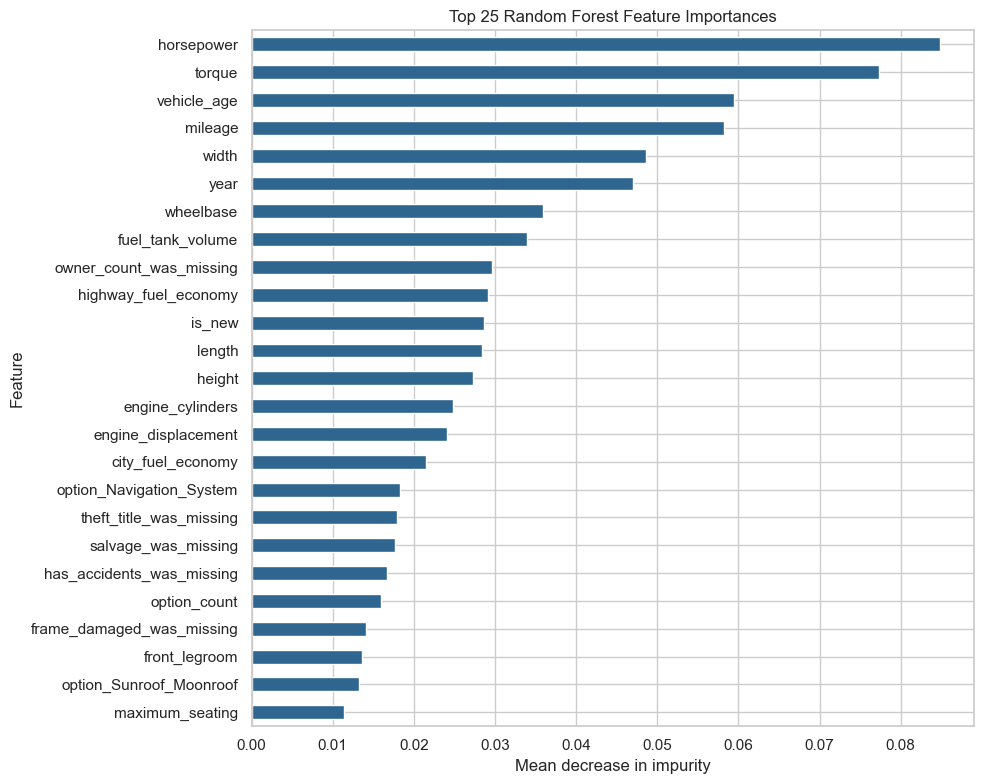

Starting predictors: 269
Predictors retained by importance: 100
Importance-model fitting time: 1,302.99 seconds


In [3]:
importance_model = RandomForestRegressor(
    n_estimators=250,
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=1,
    random_state=RANDOM_STATE,
)

importance_start = time.perf_counter()
importance_model.fit(X_train, y_train)
importance_time_sec = time.perf_counter() - importance_start

feature_importance = pd.Series(
    importance_model.feature_importances_,
    index=X_train.columns,
    name="importance",
).sort_values(ascending=False)

top_100_features = feature_importance.head(
    min(100, len(feature_importance))
).index.tolist()

assert len(top_100_features) == min(100, X_train.shape[1])
assert set(top_100_features).issubset(X_train.columns)

display(feature_importance.head(25).to_frame())

plt.figure(figsize=(10, 8))
feature_importance.head(25).sort_values().plot.barh(color="#2F6690")
plt.title("Top 25 Random Forest Feature Importances")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Starting predictors: {X_train.shape[1]}")
print(f"Predictors retained by importance: {len(top_100_features)}")
print(f"Importance-model fitting time: {importance_time_sec:,.2f} seconds")


#### Interpretation
The ranking shows that `horsepower` was the most influential predictor at 0.0848, followed by `torque` at 0.0773, `vehicle_age` at 0.0594, and `mileage` at 0.0582. Vehicle dimensions, fuel-economy measures, age, condition indicators, and major options also contributed. The importance model required about 1,302.99 seconds, showing that feature screening itself was computationally expensive. These values identify variables that helped the forest split the training data; they do not prove that the variables cause price changes.


### 2.2 Retain the top 100 Importance-Ranked Features

#### Decision
Retain exactly the 100 highest-ranked predictors from the training-only Random Forest importance table.

#### Explanation
The top-100 rule follows the required feature-selection procedure and reduces the search space before VIF analysis. It keeps a broad set of useful signals while removing 169 lower-ranked predictors. Assertions confirm that exactly 100 valid predictor names were retained and that their order follows the importance ranking.


#### Interpretation
This screening stage reduced the model matrix from 269 to 100 predictors, a reduction of 169 features or about 62.8%. The 100 predictors are candidates rather than the final set because some still contain severe linear redundancy that must be addressed by VIF filtering.


## 3. VIF Filtering

### 3.1 Calculate VIF on the Importance-Reduced Feature Set

#### Decision
Calculate VIF for the top 100 importance-ranked predictors using a reproducible 20,000-row sample drawn only from the training set.

#### Explanation
VIF measures how strongly each predictor can be linearly explained by the remaining predictors. The fixed training-only sample makes repeated VIF calculation practical while protecting the test set. Because the numeric predictors were standardized in Notebook 2, the diagonal of the inverse correlation matrix provides the VIF values. A pseudoinverse is used to remain stable when predictors are nearly collinear.


In [4]:
VIF_THRESHOLD = 10.0
VIF_SAMPLE_SIZE = 20_000


def correlation_vif(frame):
    # Calculate VIF from the inverse correlation matrix.
    correlation = np.corrcoef(frame.to_numpy(dtype=float), rowvar=False)
    inverse_correlation = np.linalg.pinv(correlation)
    return pd.Series(
        np.diag(inverse_correlation),
        index=frame.columns,
        dtype=float,
    ).replace([np.inf, -np.inf], 1e12)


vif_sample = X_train[top_100_features].sample(
    n=min(VIF_SAMPLE_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)

selected_features = top_100_features.copy()
vif_removal_log = []

# A zero-variance column cannot have a meaningful VIF.
zero_variance_features = (
    vif_sample[selected_features]
    .var()
    .loc[lambda values: values <= 1e-12]
    .index
    .tolist()
)

for feature in zero_variance_features:
    selected_features.remove(feature)
    vif_removal_log.append({
        "dropped_feature": feature,
        "VIF_at_removal": np.inf,
        "reason": "zero variance in VIF sample",
    })

while len(selected_features) > 1:
    current_vif = correlation_vif(vif_sample[selected_features])
    highest_vif = float(current_vif.max())

    if highest_vif <= VIF_THRESHOLD:
        break

    feature_to_drop = current_vif.idxmax()
    vif_removal_log.append({
        "dropped_feature": feature_to_drop,
        "VIF_at_removal": highest_vif,
        "reason": "VIF above 10",
    })
    selected_features.remove(feature_to_drop)

final_vif = correlation_vif(vif_sample[selected_features]).sort_values(
    ascending=False
)
vif_removals = pd.DataFrame(vif_removal_log)

assert final_vif.max() <= VIF_THRESHOLD + 1e-8
assert set(selected_features).issubset(top_100_features)

print(f"Top-importance predictors: {len(top_100_features)}")
print(f"Predictors removed by VIF: {len(top_100_features) - len(selected_features)}")
print(f"Final selected predictors: {len(selected_features)}")
print(f"Maximum final VIF: {final_vif.max():.4f}")

display(vif_removals)
display(final_vif.head(20).to_frame("final_VIF"))


Top-importance predictors: 100
Predictors removed by VIF: 13
Final selected predictors: 87
Maximum final VIF: 9.6338


,dropped_feature,VIF_at_removal,reason
0,year,23834.811455,VIF above 10
1,height_was_missing,1184.262096,VIF above 10
2,wheelbase_was_missing,175.799581,VIF above 10
3,is_new,38.351049,VIF above 10
4,wheelbase,33.335544,VIF above 10
5,highway_fuel_economy,24.641204,VIF above 10
6,fuel_type_Missing,22.930465,VIF above 10
7,engine_cylinders,18.903545,VIF above 10
8,fuel_tank_volume_was_missing,16.945334,VIF above 10
9,length,13.435408,VIF above 10


,final_VIF
engine_type_V8 Biodiesel,9.633812
horsepower,9.562251
fuel_type_Biodiesel,9.515751
listing_month,8.236600
listing_quarter,8.051219
height,7.576497
dealer_zip,7.477580
longitude,7.474935
torque,6.847691
option_CarPlay,6.514780


#### Interpretation
The initial VIF calculation found substantial redundancy. Thirteen predictors ultimately exceeded the threshold when evaluated during the iterative process. `year` had the largest VIF at removal, 23,834.81, because it overlaps strongly with `vehicle_age` and listing-time information. Missingness flags for height and wheelbase also showed very high redundancy. A high VIF does not mean a feature lacks predictive value; it means the same linear information is available from other retained predictors.


### 3.2 Iteratively drop features with VIF greater than 10

#### Decision
Remove the single predictor with the highest VIF, recalculate all remaining VIF values, and repeat until every retained predictor has VIF at or below 10.

#### Explanation
VIF values change after each removal, so deleting one predictor at a time is more defensible than dropping every initially high-VIF variable at once. The removal log records each deleted feature and its VIF at that moment. The final assertion enforces the required threshold and prevents a partially filtered set from being used for retraining.


#### Interpretation
The iterative procedure removed 13 of the top 100 predictors and retained 87. The removed features included `year`, `is_new`, `wheelbase`, `highway_fuel_economy`, `engine_cylinders`, `length`, `engine_displacement`, `option_count`, and several missingness or fuel indicators. The final maximum VIF was 9.6338 for `engine_type_V8 Biodiesel`, so every retained feature satisfied the threshold. Overall, the full matrix fell from 269 to 87 predictors, a reduction of 182 features or about 67.7%.


## 4. Retrain on the Selected Feature Set

### 4.1 Retrain every Notebook 3 Sklearn Model Using the Same Grids

#### Decision
Retrain Linear Regression, Random Forest, and Histogram Gradient Boosting using the 87 selected predictors, the unchanged five-fold cross-validation design, and the same parameter grids used in Notebook 3. Select each model by the lowest mean validation MAE.

#### Explanation
Holding the split, model families, grids, folds, scoring rules, and random state constant makes the number of predictors the central changed condition. `GridSearchCV(refit="neg_MAE")` chooses the best configuration and refits it on the full selected-feature training set. Setting `n_jobs=1` and `pre_dispatch=1` prevents Joblib/Loky worker failures on Windows. The final test set remains untouched until evaluation.


In [5]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"


def regression_metrics(y_true, y_pred):
    """Calculate the required regression evaluation metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


scoring = {
    "neg_MAE": make_scorer(
        mean_absolute_error,
        greater_is_better=False,
    ),
    "neg_MAPE": make_scorer(
        mean_absolute_percentage_error,
        greater_is_better=False,
    ),
    "R2": "r2",
}


# Use the same reproducible five-fold cross-validation
# procedure used for the full-feature models.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# These parameter grids must remain identical to the final
# parameter grids used in Notebook 3.
sklearn_candidates = {
    "linreg": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
            "positive": [False],
        },
    ),

    "rf": (
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        {
            "n_estimators": [50],
            "max_depth": [10, 12],
            "min_samples_leaf": [2, 5],
            "max_features": ["sqrt"],
        },
    ),

    "hgb": (
        HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            early_stopping=True,
        ),
        {
            "learning_rate": [0.05, 0.10],
            "max_leaf_nodes": [31, 63],
            "l2_regularization": [0, 1],
        },
    ),
}


def fit_sklearn_grid(name, estimator, parameter_grid):
    """Tune and evaluate one model using the selected features."""

    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring=scoring,
        refit="neg_MAE",
        cv=cv,

        # Use one worker to avoid Windows Joblib/Loky
        # multiprocessing and WMIC errors.
        n_jobs=1,
        pre_dispatch=1,

        return_train_score=False,
        verbose=1,
        error_score="raise",
    )

    # Train and tune using only the selected features.
    search.fit(
        X_train[selected_features],
        y_train,
    )

    best_index = search.best_index_

    # Evaluate the best refitted model on the unchanged test set.
    test_predictions = search.best_estimator_.predict(
        X_test[selected_features]
    )

    test_scores = regression_metrics(
        y_test,
        test_predictions,
    )

    result = {
        "model": name,
        "cv_MAE_mean": (
            -search.cv_results_["mean_test_neg_MAE"][best_index]
        ),
        "cv_MAPE_mean": (
            -search.cv_results_["mean_test_neg_MAPE"][best_index]
        ),
        "cv_R2_mean": (
            search.cv_results_["mean_test_R2"][best_index]
        ),
        "test_MAE": test_scores["MAE"],
        "test_MAPE": test_scores["MAPE"],
        "test_R2": test_scores["R2"],
        "training_time_sec": search.refit_time_,
    }

    return search, result


In [6]:
# Train, evaluate, and save each selected-feature model.

sklearn_searches = {}
model_rows = []

for model_name, (estimator, parameter_grid) in sklearn_candidates.items():
    print(
        f"\nFitting {model_name} "
        f"on {len(selected_features)} features..."
    )

    search, result = fit_sklearn_grid(
        model_name,
        estimator,
        parameter_grid,
    )

    sklearn_searches[model_name] = search
    model_rows.append(result)

    model_path = (
        MODELS_DIR /
        f"P1_N4_{model_name}_selected.pkl"
    )

    joblib.dump(
        search.best_estimator_,
        model_path,
    )

    print("Best parameters:", search.best_params_)
    print(f"CV MAE:     ${result['cv_MAE_mean']:,.2f}")
    print(f"CV MAPE:     {result['cv_MAPE_mean']:.3%}")
    print(f"CV R²:       {result['cv_R2_mean']:.4f}")
    print(f"Test MAE:   ${result['test_MAE']:,.2f}")
    print(f"Test MAPE:   {result['test_MAPE']:.3%}")
    print(f"Test R²:     {result['test_R2']:.4f}")
    print(
        f"Refit time:  "
        f"{result['training_time_sec']:.2f} seconds"
    )
    print(f"Saved: {model_path}")


sklearn_selected_metrics = (
    pd.DataFrame(model_rows)
    .set_index("model")
    .sort_index()
)

display(
    sklearn_selected_metrics.round(4)
)



Fitting linreg on 87 features...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters: {'fit_intercept': True, 'positive': False}
CV MAE:     $4,898.03
CV MAPE:     22.988%
CV R²:       0.8126
Test MAE:   $4,907.23
Test MAPE:   23.070%
Test R²:     0.8136
Refit time:  22.57 seconds
Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N4_linreg_selected.pkl

Fitting rf on 87 features...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 50}
CV MAE:     $3,050.38
CV MAPE:     13.155%
CV R²:       0.9165
Test MAE:   $3,032.32
Test MAPE:   13.099%
Test R²:     0.9204
Refit time:  19.50 seconds
Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N4_rf_selected.pkl

Fitting hgb on 87 features...
Fitting 5 folds for each of 8 candida

,cv_MAE_mean,cv_MAPE_mean,cv_R2_mean,test_MAE,test_MAPE,test_R2,training_time_sec
model,,,,,,,
hgb,2328.1282,0.0953,0.9516,2315.9180,0.0944,0.9541,13.7321
linreg,4898.0257,0.2299,0.8126,4907.2327,0.2307,0.8136,22.5674
rf,3050.3845,0.1315,0.9165,3032.3183,0.1310,0.9204,19.4970


#### Interpretation
HGB was the strongest selected-feature sklearn model. Its best settings were learning rate 0.10, 63 leaf nodes, and no L2 penalty; it achieved CV MAE $2,328.13, test MAE $2,315.92, test MAPE 9.441%, and test R² 0.9541. Random Forest ranked second among the sklearn models with test MAE $3,032.32 and R² 0.9204. Linear Regression performed worst with test MAE $4,907.23 and R² 0.8136. For all three models, CV and test metrics were close, so the reduced models generalized consistently even though their accuracy was lower than the full-feature baselines.


### 4.2 Retrain all Notebook 3 Keras Architectures and Export only the Winner

#### Decision
Evaluate NN1, NN2, and NN3 with manual five-fold cross-validation on the 87 selected predictors. Choose the architecture with the lowest mean validation MAE, then train a fresh version of only that winner on all selected-feature training rows for the median best-epoch count.

#### Explanation
Treating the architectures as candidates allows the choice to be based on validation evidence rather than the test set. Each fold starts with fresh weights and reports MAE, MAPE, R², and the best epoch. Mean results compare expected accuracy, while standard deviations show fold-to-fold stability. A fresh final model avoids exporting any fold-specific network.


In [7]:
try:
    import tensorflow as tf
    from tensorflow import keras
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is not installed in this Jupyter kernel. Activate the "
        "Notebook 3 environment and run: python -m pip install tensorflow"
    ) from exc

tf.keras.utils.set_random_seed(RANDOM_STATE)

keras_architectures = {
    "nn1": [128, 64],
    "nn2": [256, 128, 64],
    "nn3": [128, 64, 32],
}


def build_network(number_of_features, hidden_layers, architecture_name):
    model = keras.Sequential(name=architecture_name)
    model.add(keras.layers.Input(shape=(number_of_features,)))

    for units in hidden_layers:
        model.add(keras.layers.Dense(units, activation="relu"))
        if architecture_name == "nn3":
            model.add(keras.layers.Dropout(0.15))

    model.add(keras.layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mae",
    )
    return model


def cross_validate_networks(X, y, architectures):
    folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_rows = []

    for architecture_name, hidden_layers in architectures.items():
        print(f"\nCross-validating {architecture_name}: {hidden_layers}")

        for fold_number, (train_index, validation_index) in enumerate(
            folds.split(X),
            start=1,
        ):
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(RANDOM_STATE + fold_number)

            model = build_network(
                X.shape[1],
                hidden_layers,
                architecture_name,
            )

            early_stopping = keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
            )

            history = model.fit(
                X[train_index],
                y[train_index],
                validation_data=(X[validation_index], y[validation_index]),
                epochs=25,
                batch_size=512,
                verbose=0,
                callbacks=[early_stopping],
            )

            predictions = model.predict(
                X[validation_index],
                verbose=0,
            ).ravel()
            scores = regression_metrics(y[validation_index], predictions)

            best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

            fold_rows.append({
                "model": architecture_name,
                "fold": fold_number,
                "MAE": scores["MAE"],
                "MAPE": scores["MAPE"],
                "R2": scores["R2"],
                "best_epoch": best_epoch,
            })

            print(
                f"Fold {fold_number}: MAE=${scores['MAE']:,.2f}, "
                f"MAPE={scores['MAPE']:.4f}, R²={scores['R2']:.4f}, "
                f"best epoch={best_epoch}"
            )

    fold_results = pd.DataFrame(fold_rows)

    architecture_summary = fold_results.groupby("model").agg(
        cv_MAE_mean=("MAE", "mean"),
        cv_MAE_std=("MAE", "std"),
        cv_MAPE_mean=("MAPE", "mean"),
        cv_MAPE_std=("MAPE", "std"),
        cv_R2_mean=("R2", "mean"),
        cv_R2_std=("R2", "std"),
        median_best_epoch=("best_epoch", "median"),
    )

    return fold_results, architecture_summary


In [8]:
X_train_nn = X_train[selected_features].to_numpy(dtype="float32")
y_train_nn = y_train.to_numpy(dtype="float32")
X_test_nn = X_test[selected_features].to_numpy(dtype="float32")

keras_fold_results, keras_cv_summary = cross_validate_networks(
    X_train_nn,
    y_train_nn,
    keras_architectures,
)

display(keras_fold_results.round(4))
display(keras_cv_summary.round(4))

winning_network_name = keras_cv_summary["cv_MAE_mean"].idxmin()
winning_layers = keras_architectures[winning_network_name]
final_epochs = max(
    1,
    int(round(keras_cv_summary.loc[winning_network_name, "median_best_epoch"])),
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

final_network = build_network(
    len(selected_features),
    winning_layers,
    winning_network_name,
)

training_start = time.perf_counter()
final_network.fit(
    X_train_nn,
    y_train_nn,
    epochs=final_epochs,
    batch_size=512,
    verbose=0,
)
keras_refit_time = time.perf_counter() - training_start

keras_test_predictions = final_network.predict(
    X_test_nn,
    verbose=0,
).ravel()
keras_test_scores = regression_metrics(y_test, keras_test_predictions)

model_rows.append({
    "model": winning_network_name,
    "cv_MAE_mean": keras_cv_summary.loc[winning_network_name, "cv_MAE_mean"],
    "cv_MAPE_mean": keras_cv_summary.loc[winning_network_name, "cv_MAPE_mean"],
    "cv_R2_mean": keras_cv_summary.loc[winning_network_name, "cv_R2_mean"],
    "test_MAE": keras_test_scores["MAE"],
    "test_MAPE": keras_test_scores["MAPE"],
    "test_R2": keras_test_scores["R2"],
    "training_time_sec": keras_refit_time,
})

keras_model_path = (
    MODELS_DIR / f"P1_N4_{winning_network_name}_selected.keras"
)
final_network.save(keras_model_path)

print(f"Winning architecture: {winning_network_name} {winning_layers}")
print(f"Final full-training epochs: {final_epochs}")
print(f"Test MAE: ${keras_test_scores['MAE']:,.2f}")
print(f"Test R²: {keras_test_scores['R2']:.4f}")
print(f"Final training time: {keras_refit_time:.2f} seconds")
print(f"Saved: {keras_model_path}")



Cross-validating nn1: [128, 64]

Fold 1: MAE=$3,092.38, MAPE=0.1155, R²=0.9010, best epoch=25
Fold 2: MAE=$3,127.91, MAPE=0.1148, R²=0.8953, best epoch=25
Fold 3: MAE=$3,112.66, MAPE=0.1152, R²=0.8972, best epoch=25
Fold 4: MAE=$3,038.49, MAPE=0.1144, R²=0.9057, best epoch=25
Fold 5: MAE=$3,089.17, MAPE=0.1152, R²=0.9017, best epoch=25

Cross-validating nn2: [256, 128, 64]
Fold 1: MAE=$2,566.06, MAPE=0.1003, R²=0.9332, best epoch=25
Fold 2: MAE=$2,638.01, MAPE=0.0994, R²=0.9228, best epoch=25
Fold 3: MAE=$2,639.00, MAPE=0.0992, R²=0.9236, best epoch=25
Fold 4: MAE=$2,544.03, MAPE=0.0972, R²=0.9319, best epoch=25
Fold 5: MAE=$2,555.97, MAPE=0.0986, R²=0.9329, best epoch=25

Cross-validating nn3: [128, 64, 32]
Fold 1: MAE=$2,989.04, MAPE=0.1106, R²=0.9090, best epoch=25
Fold 2: MAE=$3,061.22, MAPE=0.1114, R²=0.9006, best epoch=25
Fold 3: MAE=$3,052.50, MAPE=0.1118, R²=0.9033, best epoch=25
Fold 4: MAE=$2,952.57, MAPE=0.1101, R²=0.9123, best epoch=25
Fold 5: MAE=$3,002.59, MAPE=0.1109, R

,model,fold,MAE,MAPE,R2,best_epoch
0,nn1,1,3092.3840,0.1155,0.9010,25
1,nn1,2,3127.9092,0.1148,0.8953,25
2,nn1,3,3112.6614,0.1152,0.8972,25
3,nn1,4,3038.4861,0.1144,0.9057,25
4,nn1,5,3089.1650,0.1152,0.9017,25
5,nn2,1,2566.0557,0.1003,0.9332,25
6,nn2,2,2638.0146,0.0994,0.9228,25
7,nn2,3,2638.9993,0.0992,0.9236,25
8,nn2,4,2544.0349,0.0972,0.9319,25
9,nn2,5,2555.9658,0.0986,0.9329,25


,cv_MAE_mean,cv_MAE_std,cv_MAPE_mean,cv_MAPE_std,cv_R2_mean,cv_R2_std,median_best_epoch
model,,,,,,,
nn1,3092.1211,33.8682,0.1150,0.0004,0.9002,0.0041,25.0
nn2,2588.6141,46.2092,0.0989,0.0011,0.9289,0.0052,25.0
nn3,3011.5830,45.3020,0.1110,0.0007,0.9067,0.0047,25.0


Winning architecture: nn2 [256, 128, 64]
Final full-training epochs: 25
Test MAE: $2,484.31
Test R²: 0.9364
Final training time: 53.71 seconds
Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N4_nn2_selected.keras


#### Interpretation
NN2, with hidden layers of 256, 128, and 64 units, was the clear neural-network winner. Its mean CV MAE was $2,588.61, compared with $3,092.12 for NN1 and $3,011.58 for NN3. NN2 also had the best mean CV MAPE at 9.89% and the highest mean CV R² at 0.9289. Its final test MAE was $2,484.31, test MAPE was 9.64%, and test R² was 0.9364. All folds reached epoch 25, which suggests the imposed epoch limit—not early stopping—determined the stopping point; a higher cap could be tested during training-only tuning if more computation is available.


## 5. Before/After Comparison

### 5.1 Build the Selected-Model Performance Table in Notebook 3's Exact Shape

#### Decision
Combine the three selected-feature sklearn results with the winning Keras result in the same seven-column format used by Notebook 3.

#### Explanation
Using an identical schema supports direct model-by-model comparison. MAE is reported in dollars, MAPE as a proportion, R² as explained variance, and training time as the final full-training refit rather than the entire search. Only NN2 is included because it was selected from the three neural architectures by cross-validation.


In [9]:
selected_metrics = (
    pd.DataFrame(model_rows)
    .set_index("model")
    [required_metric_cols]
    .sort_index()
)

assert list(selected_metrics.columns) == required_metric_cols

comparison = (
    baseline_metrics[required_metric_cols]
    .add_prefix("before_")
    .join(selected_metrics.add_prefix("after_"), how="outer")
)

for metric in ["test_MAE", "test_MAPE", "test_R2", "training_time_sec"]:
    comparison[f"change_{metric}"] = (
        comparison[f"after_{metric}"]
        - comparison[f"before_{metric}"]
    )

comparison["MAE_change_pct"] = (
    comparison["change_test_MAE"]
    / comparison["before_test_MAE"]
    * 100
)
comparison["R2_change_pct"] = (
    comparison["change_test_R2"]
    / comparison["before_test_R2"]
    * 100
)
comparison["time_change_pct"] = (
    comparison["change_training_time_sec"]
    / comparison["before_training_time_sec"]
    * 100
)

comparison["accuracy_result"] = np.where(
    comparison["change_test_MAE"] < 0,
    "Improved",
    "Worse",
)
comparison["speed_result"] = np.where(
    comparison["change_training_time_sec"] < 0,
    "Faster",
    "Slower",
)

display(selected_metrics.round(4))
display(comparison.round(4))

print(
    "Interpretation rule: negative MAE/MAPE change is better; "
    "positive R² change is better; negative time change is faster."
)


,cv_MAE_mean,cv_MAPE_mean,cv_R2_mean,test_MAE,test_MAPE,test_R2,training_time_sec
model,,,,,,,
hgb,2328.1282,0.0953,0.9516,2315.9180,0.0944,0.9541,13.7321
linreg,4898.0257,0.2299,0.8126,4907.2327,0.2307,0.8136,22.5674
nn2,2588.6141,0.0989,0.9289,2484.3074,0.0964,0.9364,53.7062
rf,3050.3845,0.1315,0.9165,3032.3183,0.1310,0.9204,19.4970


,before_cv_MAE_mean,before_cv_MAPE_mean,before_cv_R2_mean,before_test_MAE,before_test_MAPE,before_test_R2,before_training_time_sec,after_cv_MAE_mean,after_cv_MAPE_mean,after_cv_R2_mean,...,after_training_time_sec,change_test_MAE,change_test_MAPE,change_test_R2,change_training_time_sec,MAE_change_pct,R2_change_pct,time_change_pct,accuracy_result,speed_result
model,,,,,,,,,,,,,,,,,,,,,
hgb,1948.3318,0.0790,0.9644,1948.3525,0.0792,0.9664,475.9897,2328.1282,0.0953,0.9516,...,13.7321,367.5656,0.0152,-0.0123,-462.2576,18.8655,-1.2766,-97.1150,Worse,Faster
linreg,4401.8370,0.2074,0.8451,4409.6621,0.2080,0.8459,27.7468,4898.0257,0.2299,0.8126,...,22.5674,497.5706,0.0228,-0.0323,-5.1794,11.2836,-3.8173,-18.6665,Worse,Faster
nn2,2129.6609,0.0810,0.9516,2059.2375,0.0788,0.9563,755.9213,2588.6141,0.0989,0.9289,...,53.7062,425.0698,0.0176,-0.0199,-702.2151,20.6421,-2.0793,-92.8953,Worse,Faster
rf,2384.1267,0.1032,0.9449,2325.5978,0.1015,0.9503,46.0719,3050.3845,0.1315,0.9165,...,19.4970,706.7205,0.0295,-0.0299,-26.5749,30.3888,-3.1461,-57.6814,Worse,Faster


Interpretation rule: negative MAE/MAPE change is better; positive R² change is better; negative time change is faster.


#### Interpretation
HGB remained the best selected-feature model with test MAE $2,315.92 and test R² 0.9541. NN2 followed with test MAE $2,484.31 and R² 0.9364, Random Forest recorded $3,032.32 and 0.9204, and Linear Regression recorded $4,907.23 and 0.8136. The close CV and test values for each model indicate stable generalization. However, this table alone does not establish whether selection helped; that requires comparison with the full-feature baselines.


### 5.2 Compare Notebook 3 and Notebook 4 Row by Row

#### Decision
Join the full-feature and selected-feature metric tables by model name and compute each after-minus-before change in test MAE, MAPE, R², and final-refit time.

#### Explanation
For MAE and MAPE, a negative change indicates improvement. For R², a positive change indicates improvement. For time, a negative change indicates faster fitting. Percentage changes make the size of each model's tradeoff easier to compare while preserving the absolute metric differences.


#### Interpretation
Every model lost predictive accuracy after selection. HGB's test MAE increased by $367.57 or 18.87%, and its R² decreased by 0.0123. Linear Regression's MAE increased by $497.57 or 11.28%, and its R² decreased by 0.0323. NN2's MAE increased by $425.07 or 20.64%, and its R² decreased by 0.0199. Random Forest had the largest relative MAE deterioration: an increase of $706.72 or 30.39%, with R² decreasing by 0.0299. Therefore, the 87-feature set did not improve test accuracy for any evaluated model.


### 5.3 Quantify the Speed Benefit and Accuracy Tradeoff

#### Decision
Compare full-feature and selected-feature test MAE and final-refit time using both charts and calculated changes.

#### Explanation
The selected set can still offer operational value if it materially reduces fitting time, storage, or complexity. The accuracy and time plots show different parts of the tradeoff, while the calculated deltas prevent conclusions based only on visual scale. Timing comparisons are specific to this computer and to the stored definition of final-refit time.


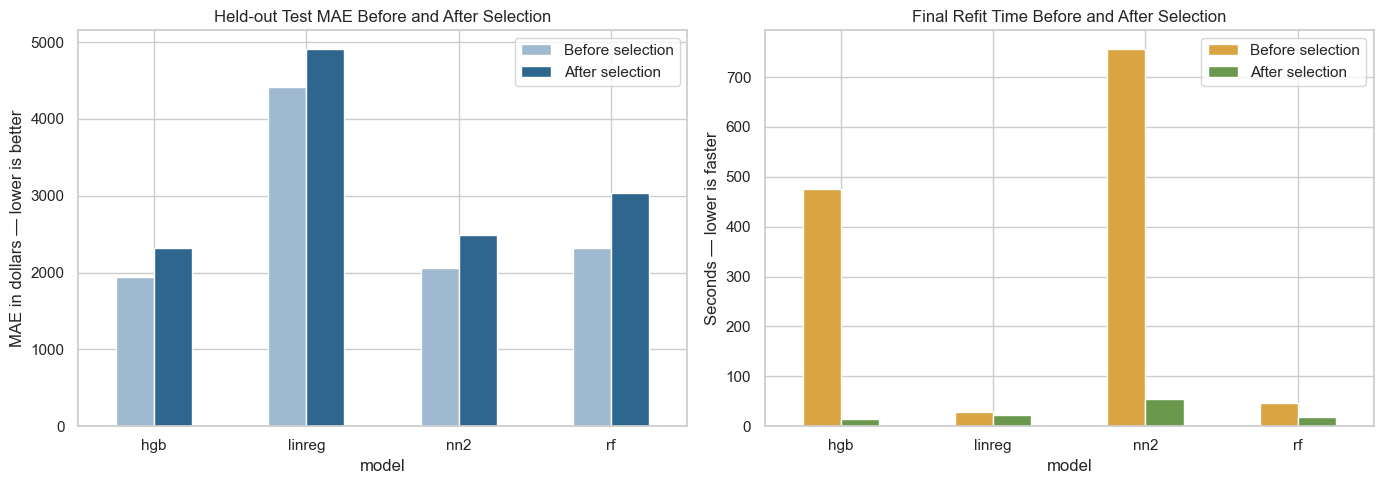

In [10]:
plot_frame = comparison.dropna(
    subset=["before_test_MAE", "after_test_MAE"]
).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_frame[["before_test_MAE", "after_test_MAE"]].rename(
    columns={
        "before_test_MAE": "Before selection",
        "after_test_MAE": "After selection",
    }
).plot.bar(ax=axes[0], color=["#9FBAD0", "#2F6690"])
axes[0].set_title("Held-out Test MAE Before and After Selection")
axes[0].set_ylabel("MAE in dollars — lower is better")
axes[0].tick_params(axis="x", rotation=0)

plot_frame[["before_training_time_sec", "after_training_time_sec"]].rename(
    columns={
        "before_training_time_sec": "Before selection",
        "after_training_time_sec": "After selection",
    }
).plot.bar(ax=axes[1], color=["#D9A441", "#6A994E"])
axes[1].set_title("Final Refit Time Before and After Selection")
axes[1].set_ylabel("Seconds — lower is faster")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


#### Interpretation
All four selected-feature models refitted faster. HGB fell from 475.99 to 13.73 seconds, a 97.12% reduction. NN2 fell from 755.92 to 53.71 seconds, a 92.90% reduction. Random Forest fell from 46.07 to 19.50 seconds, a 57.68% reduction, and Linear Regression fell from 27.75 to 22.57 seconds, an 18.67% reduction. The speed gains were substantial, especially for HGB and NN2, but they came with higher test errors for every model.


### 5.4 Document What Changed, What Did Not, And Why

#### Decision
Describe feature selection as an accuracy-efficiency tradeoff rather than calling it a universal improvement.

#### Explanation
The data split, target, model families, parameter grids, folds, and evaluation metrics remained unchanged. The principal change was reducing the predictor count from 269 to 87 through Random Forest importance and VIF filtering. The removed variables contained redundant information, but some also carried useful predictive signal. Because algorithms use weak, correlated, and nonlinear information differently, the effect of removal varies by model.


#### Interpretation
HGB remained the best model after selection, but its full-feature version was still more accurate. Linear Regression had the smallest percentage increase in MAE, while Random Forest had the largest. HGB and NN2 received the greatest refit-time reductions. The evidence supports choosing the full-feature HGB when predictive accuracy is the main goal. The selected-feature HGB is a reasonable efficiency-focused alternative when faster fitting and a smaller input set justify an average MAE increase of about $367.57.


## 6. Export

### 6.1 Save `selected_train.csv` and `selected_test.csv` With Price And Metadata

#### Decision
Export the same 87 selected predictors in the same order for training and testing, followed by unscaled `price` and all 18 preserved metadata columns.

#### Explanation
The target is needed for evaluation, and the metadata is needed for Notebook 5's subgroup fairness audit. Neither belongs in the model predictor matrix. Assertions verify identical schemas, unchanged row counts, preservation of all metadata, and exclusion of the 182 predictors that were not selected.


In [11]:
selected_export_cols = selected_features + ["price"] + metadata_cols

selected_train = train[selected_export_cols].copy()
selected_test = test[selected_export_cols].copy()

selected_train_path = DATA_DIR / "selected_train.csv"
selected_test_path = DATA_DIR / "selected_test.csv"
selected_metrics_path = DATA_DIR / "model_metrics_selected.csv"

selected_train.to_csv(selected_train_path, index=False)
selected_test.to_csv(selected_test_path, index=False)
selected_metrics.to_csv(selected_metrics_path)

pd.DataFrame({"selected_feature": selected_features}).to_csv(
    DATA_DIR / "selected_features.csv",
    index=False,
)
feature_importance.rename_axis("feature").reset_index().to_csv(
    DATA_DIR / "feature_importance_ranking.csv",
    index=False,
)
vif_removals.to_csv(DATA_DIR / "vif_removal_log.csv", index=False)
final_vif.rename("VIF").rename_axis("feature").reset_index().to_csv(
    DATA_DIR / "final_vif.csv",
    index=False,
)
comparison.to_csv(DATA_DIR / "model_comparison_before_after.csv")

assert selected_train.columns.equals(selected_test.columns)
assert "price" in selected_train.columns
assert all(column in selected_train.columns for column in metadata_cols)
assert all(column not in metadata_cols + ["price"] for column in selected_features)
assert len(selected_train) == len(train)
assert len(selected_test) == len(test)
assert selected_train_path.exists()
assert selected_test_path.exists()
assert selected_metrics_path.exists()

expected_sklearn_models = [
    MODELS_DIR / f"P1_N4_{name}_selected.pkl"
    for name in sklearn_candidates
]
assert all(path.exists() for path in expected_sklearn_models)
assert keras_model_path.exists()

print(f"Saved: {selected_train_path}")
print(f"Saved: {selected_test_path}")
print(f"Saved: {selected_metrics_path}")
print(f"Selected predictors: {len(selected_features)}")
print(f"Metadata columns retained: {len(metadata_cols)}")
print("All required selected models and audit files were saved.")


Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\selected_train.csv
Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\selected_test.csv
Saved: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\model_metrics_selected.csv
Selected predictors: 87
Metadata columns retained: 18
All required selected models and audit files were saved.


#### Interpretation
The export completed successfully with 87 selected predictors and 18 metadata columns. The output also confirms that `selected_train.csv`, `selected_test.csv`, `model_metrics_selected.csv`, all three selected sklearn models, and the winning NN2 model were saved. Notebook 5 must continue to exclude `price` and the metadata fields from `X` and must reuse these rows without creating another split.


### 6.2 Save `model_metrics_selected.csv`

#### Decision
Save the selected-feature performance table with one row for each final model and the same seven metric columns used in `model_metrics.csv`.

#### Explanation
The consistent format preserves a reproducible record of the selected-feature results and allows later notebooks to compare them with the full-feature baseline without rerunning the expensive importance model, VIF loop, grid searches, or neural-network cross-validation. Supporting audit tables document importance rankings, VIF removals, final VIF values, and before-and-after changes.


#### Interpretation
The completed selected-metrics output contains four final rows—HGB, Linear Regression, NN2, and Random Forest—and the required CV, test, and refit-time fields. These values are the authoritative Notebook 4 results. The table shows HGB as the best selected-feature model and preserves the evidence that all selected models became faster but less accurate.


### 6.3 Save Selected sklearn and Keras Models Using `_selected` filenames

#### Decision
Save each fitted sklearn `best_estimator_` as `P1_N4_<model>_selected.pkl` and save only the cross-validation-winning neural network as `P1_N4_nn2_selected.keras`.

#### Explanation
The `_selected` suffix distinguishes the 87-feature models from Notebook 3's 269-feature models. Saving the refitted estimators ensures that downstream work uses the exact fitted objects associated with the reported results. The selected-feature list and its order must accompany these models because the estimators expect the same 87 inputs used during training.


#### Interpretation
The export assertions confirm that the three sklearn model files and the winning NN2 Keras file exist. If Notebook 5 evaluates the best selected-feature model, it should use `P1_N4_hgb_selected.pkl` with `selected_test.csv` and the exact selected-feature order. If Notebook 5 specifically requires another model for a method such as SHAP, that choice should be stated separately rather than presented as the most accurate model.


## Over Understaning And Outcome

Notebook 4 completed the required two-stage feature-selection process. Random Forest importance reduced the original 269 predictors to the top 100, and iterative VIF filtering removed 13 redundant predictors. The final model matrix contained 87 predictors, which was 182 fewer than the original matrix and represented a reduction of about 67.7%.

After retraining on the unchanged split, HGB remained the best selected-feature model with a test MAE of $2,315.92, test MAPE of 9.441%, and test R² of 0.9541. NN2 was the best neural architecture and the second-best selected model overall, with test MAE of $2,484.31 and test R² of 0.9364.

The before-and-after comparison shows that feature selection improved efficiency but not predictive accuracy. Test MAE increased for HGB by 18.87%, Linear Regression by 11.28%, NN2 by 20.64%, and Random Forest by 30.39%. At the same time, final-refit time decreased for every model, including reductions of 97.12% for HGB and 92.90% for NN2.

Therefore, the full-feature HGB remains the recommended model when accuracy is the priority. The 87-feature HGB is an efficiency-focused alternative because it trains much faster and uses a substantially smaller feature set, but its average test error is about $367.57 higher. The final decision should depend on whether the project values maximum price-prediction accuracy or reduced training cost and model complexity.
